In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

PROJECT_DIR = "/mnt/e/kartik/Mango flower disease detection DL project"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "mango_dataset"
)

VAL_DIR = os.path.join(
    DATASET_DIR,
    "validation"
)

TEST_DIR = os.path.join(
    DATASET_DIR,
    "test"
)

MODEL_DIR = os.path.join(
    DATASET_DIR,
    "models"
)

IMG_SIZE = (256, 256)
BATCH_SIZE = 32

validation_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = validation_ds.class_names

print("Classes:")
for i, name in enumerate(class_names):
    print(i, name)

I0000 00:00:1790191836.567993     991 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790191836.966414     991 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790191839.008462     991 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 139 files belonging to 7 classes.


W0000 00:00:1790191842.036995     991 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


Found 151 files belonging to 7 classes.
Classes:
0 anthracnose
1 anthracnose & mango malformation
2 anthracnose & powdery mildew
3 healthy
4 mango malformation
5 mango malformation & powdery mildew
6 powdery mildew


W0000 00:00:1790191842.041676     991 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790191842.266252     991 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [2]:
y_val_true = np.concatenate(
    [labels.numpy() for images, labels in validation_ds]
)

y_test_true = np.concatenate(
    [labels.numpy() for images, labels in test_ds]
)

print("Validation samples:", len(y_val_true))
print("Test samples:", len(y_test_true))

Validation samples: 139
Test samples: 151


In [3]:
models_to_compare = [
    "best_convnext_tiny_phase1.keras",
    "best_efficientnetv2b0_finetune_20layers.keras",
    "best_efficientnetv2m_phase1.keras",
    "best_phase1_model.keras",
    "best_phase1_recovered.keras",
    "best_phase2_finetuned_model.keras",
    "best_phase2_model.keras",
    "experiment_A_baseline_best.keras",
    "experiment_B_classweights_best.keras",
    "latest_phase1_recovered.keras"
]

print("Models to compare:")
for model_name in models_to_compare:
    print("-", model_name)

Models to compare:
- best_convnext_tiny_phase1.keras
- best_efficientnetv2b0_finetune_20layers.keras
- best_efficientnetv2m_phase1.keras
- best_phase1_model.keras
- best_phase1_recovered.keras
- best_phase2_finetuned_model.keras
- best_phase2_model.keras
- experiment_A_baseline_best.keras
- experiment_B_classweights_best.keras
- latest_phase1_recovered.keras


In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

comparison_results = []

for model_name in models_to_compare:

    print("\n" + "=" * 80)
    print("Evaluating:", model_name)
    print("=" * 80)

    model_path = os.path.join(
        MODEL_DIR,
        model_name
    )

    try:

        model = keras.models.load_model(
            model_path
        )

        y_val_prob = model.predict(
            validation_ds,
            verbose=0
        )

        y_val_pred = np.argmax(
            y_val_prob,
            axis=1
        )

        accuracy = accuracy_score(
            y_val_true,
            y_val_pred
        )

        macro_precision = precision_score(
            y_val_true,
            y_val_pred,
            average="macro",
            zero_division=0
        )

        macro_recall = recall_score(
            y_val_true,
            y_val_pred,
            average="macro",
            zero_division=0
        )

        macro_f1 = f1_score(
            y_val_true,
            y_val_pred,
            average="macro",
            zero_division=0
        )

        weighted_f1 = f1_score(
            y_val_true,
            y_val_pred,
            average="weighted",
            zero_division=0
        )

        comparison_results.append({
            "Model": model_name,
            "Validation Accuracy": accuracy,
            "Validation Macro Precision": macro_precision,
            "Validation Macro Recall": macro_recall,
            "Validation Macro F1": macro_f1,
            "Validation Weighted F1": weighted_f1
        })

        print(f"Accuracy     : {accuracy:.4f}")
        print(f"Macro F1     : {macro_f1:.4f}")
        print(f"Macro Recall : {macro_recall:.4f}")

        del model

    except Exception as e:

        print("FAILED:", type(e).__name__)
        print(e)


Evaluating: best_convnext_tiny_phase1.keras


I0000 00:00:1790191919.749009    1493 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790191926.750052    1493 service.cc:153] XLA service 0x7288148d8300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790191926.750106    1493 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
E0000 00:00:1790191927.785173    1493 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1790191927.982618    1493 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
E0000 00:00:1790191928.751946    1493 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Sys

Accuracy     : 0.7698
Macro F1     : 0.6901
Macro Recall : 0.6837

Evaluating: best_efficientnetv2b0_finetune_20layers.keras
Accuracy     : 0.8561
Macro F1     : 0.7829
Macro Recall : 0.7694

Evaluating: best_efficientnetv2m_phase1.keras
Accuracy     : 0.7410
Macro F1     : 0.6677
Macro Recall : 0.6795

Evaluating: best_phase1_model.keras


I0000 00:00:1790191986.988451    1496 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
E0000 00:00:1790191990.728843    1496 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790191992.700316    1496 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790191993.541223    1496 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790192001.589371    1493 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790192002.799212    1493 cuda_timer.cc:8

Accuracy     : 0.8633
Macro F1     : 0.7885
Macro Recall : 0.7751

Evaluating: best_phase1_recovered.keras
Accuracy     : 0.8273
Macro F1     : 0.7632
Macro Recall : 0.7515

Evaluating: best_phase2_finetuned_model.keras
Accuracy     : 0.8489
Macro F1     : 0.7657
Macro Recall : 0.7637

Evaluating: best_phase2_model.keras
Accuracy     : 0.8489
Macro F1     : 0.8004
Macro Recall : 0.8068

Evaluating: experiment_A_baseline_best.keras
Accuracy     : 0.8345
Macro F1     : 0.7876
Macro Recall : 0.7587

Evaluating: experiment_B_classweights_best.keras
Accuracy     : 0.7842
Macro F1     : 0.7619
Macro Recall : 0.7477

Evaluating: latest_phase1_recovered.keras
Accuracy     : 0.8417
Macro F1     : 0.7956
Macro Recall : 0.7825


In [5]:
comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df = comparison_df.sort_values(
    by="Validation Macro F1",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Validation Accuracy,Validation Macro Precision,Validation Macro Recall,Validation Macro F1,Validation Weighted F1
0,best_phase2_model.keras,0.848921,0.811129,0.806825,0.800352,0.844074
1,latest_phase1_recovered.keras,0.841727,0.816141,0.782487,0.795638,0.840190
2,best_phase1_model.keras,0.863309,0.813450,0.775099,0.788465,0.859625
3,experiment_A_baseline_best.keras,0.834532,0.837051,0.758659,0.787643,0.831921
4,best_efficientnetv2b0_finetune_20layers.keras,0.856115,0.808291,0.769385,0.782946,0.852473
5,best_phase2_finetuned_model.keras,0.848921,0.783187,0.763671,0.765697,0.845830
6,best_phase1_recovered.keras,0.827338,0.785678,0.751519,0.763170,0.825653
7,experiment_B_classweights_best.keras,0.784173,0.784877,0.747729,0.761928,0.788857
8,best_convnext_tiny_phase1.keras,0.769784,0.716455,0.683650,0.690093,0.762734
9,best_efficientnetv2m_phase1.keras,0.741007,0.674415,0.679546,0.667730,0.743244


In [6]:
from tensorflow import keras
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_phase2_model.keras"
)

best_model = keras.models.load_model(
    BEST_MODEL_PATH
)

print("Loaded:", BEST_MODEL_PATH)

Loaded: /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/best_phase2_model.keras


In [7]:
y_test_prob_best = best_model.predict(
    test_ds,
    verbose=1
)

y_test_pred_best = np.argmax(
    y_test_prob_best,
    axis=1
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 492ms/step


In [8]:
print("=" * 80)
print("BEST MODEL — TEST CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test_true,
        y_test_pred_best,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

test_accuracy_best = accuracy_score(
    y_test_true,
    y_test_pred_best
)

test_macro_precision_best = precision_score(
    y_test_true,
    y_test_pred_best,
    average="macro",
    zero_division=0
)

test_macro_recall_best = recall_score(
    y_test_true,
    y_test_pred_best,
    average="macro",
    zero_division=0
)

test_macro_f1_best = f1_score(
    y_test_true,
    y_test_pred_best,
    average="macro",
    zero_division=0
)

print()
print(f"Test Accuracy     : {test_accuracy_best:.4f}")
print(f"Test Macro F1     : {test_macro_f1_best:.4f}")
print(f"Test Macro Recall : {test_macro_recall_best:.4f}")

BEST MODEL — TEST CLASSIFICATION REPORT
                                     precision    recall  f1-score   support

                        anthracnose     0.9259    0.7812    0.8475        32
   anthracnose & mango malformation     1.0000    0.8000    0.8889         5
       anthracnose & powdery mildew     0.7931    0.7931    0.7931        29
                            healthy     0.9143    0.9412    0.9275        34
                 mango malformation     0.7826    1.0000    0.8780        18
mango malformation & powdery mildew     0.8333    0.8333    0.8333         6
                     powdery mildew     0.7037    0.7037    0.7037        27

                           accuracy                         0.8344       151
                          macro avg     0.8504    0.8361    0.8389       151
                       weighted avg     0.8398    0.8344    0.8338       151


Test Accuracy     : 0.8344
Test Macro F1     : 0.8389
Test Macro Recall : 0.8361


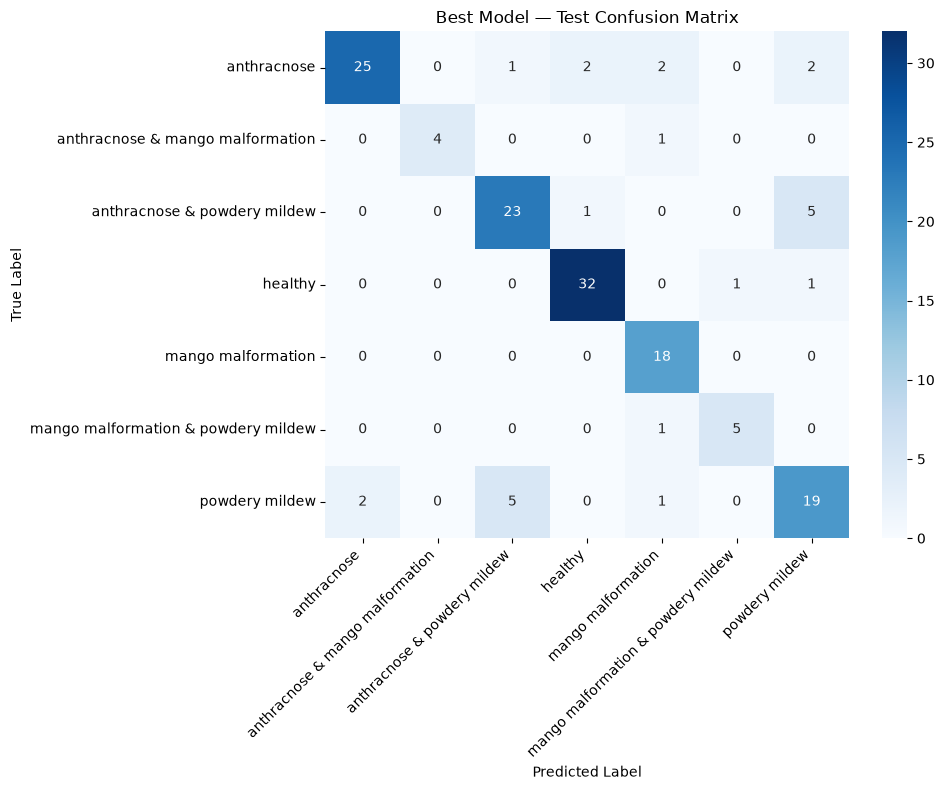

In [9]:
cm_best = confusion_matrix(
    y_test_true,
    y_test_pred_best
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Best Model — Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
import shutil
import os

source_model = os.path.join(
    PROJECT_DIR,
    "mango_dataset",
    "models",
    "best_phase1_model.keras"
)

destination_model = os.path.join(
    PROJECT_DIR,
    "deployment",
    "model",
    "mango_disease_model.keras"
)

shutil.copy2(
    source_model,
    destination_model
)

print("Model copied to:")
print(destination_model)

Model copied to:
/mnt/e/kartik/Mango flower disease detection DL project/deployment/model/mango_disease_model.keras
